In [83]:
import matplotlib.pyplot as plt
import numpy as np
import copy
import math

In [112]:
data = np.loadtxt("my_data/data2.txt",delimiter = ',')
x_norm=data[:,0]
y=data[:,1]
X_norm=np.c_[x_norm,x_norm**2,x_norm**3]
omean=np.mean(X_norm,axis=0)
ostd=np.std(X_norm,axis=0)
X=(X_norm-omean)/ostd
t=X_norm.shape[1]
w_unit=np.zeros(t)
b_unit=0

In [113]:
def predict(x,w,b):
    p=np.dot(x,w)+b
    return p

In [114]:
def compute_cost(X,y,w,b):
    m=X.shape[0]
    cost=0.0
    for i in range(m):
        cost+=(predict(X[i],w,b)-y[i])**2
    return cost/(2*m)

In [115]:
def compute_gradient(X,y,w,b):
    m,n=X.shape
    f_w=np.zeros((n,))
    f_b=0
    for i in range(m):
        err=predict(X[i],w,b)-y[i]
        f_b+=err
        for j in range(n):
            f_w[j]+=err*X[i,j]
    return f_w/m,f_b/m

In [116]:
def gradient_descent(X,w_in,y,b_in,cost_function,gradient_function,alpha,num_iters):
    w=copy.deepcopy(w_in)
    b=b_in
    cost=[]
    for i in range(num_iters):
        f_w,f_b=gradient_function(X,y,w,b)
        w-=alpha*f_w
        b-=alpha*f_b
        if(i<10000):
            cost.append(cost_function(X,y,w,b))
        if(i%math.ceil(num_iters/10)==0):
            print(f"cnt{i:4d}: cost{cost[-1]:8.6f}")
    return w,b,cost

In [117]:
alpha=0.01
num_iters=10000
w,b,J=gradient_descent(X,w_unit,y,b_unit,compute_cost,compute_gradient,alpha,num_iters)
b=b-np.dot(omean,w/ostd)
w=w/ostd
print(w,b)

cnt   0: cost12336.039077
cnt1000: cost114.658859
cnt2000: cost33.788135
cnt3000: cost17.742226
cnt4000: cost14.558487
cnt5000: cost13.926788
cnt6000: cost13.801450
cnt7000: cost13.776581
cnt8000: cost13.771647
cnt9000: cost13.770668
[-2.09045729 -2.67012514  3.21705266] 1.9087628783943416


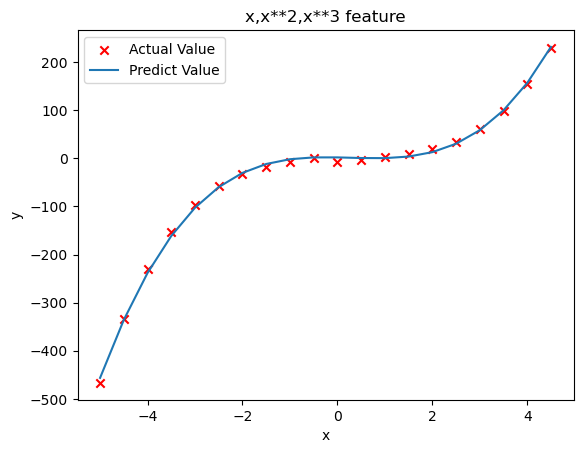

In [118]:
plt.scatter(x_norm,y,marker='x',c='r',label="Actual Value")
plt.title("x,x**2,x**3 feature")
plt.plot(x_norm,X_norm@w+b,label="Predict Value")
plt.xlabel("x");plt.ylabel("y");plt.legend();plt.show()